In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import math

In [2]:
algos = ['baseline', 'flashnet', 'small_surrogate_dt_depth5', 'small_hierarchy_p95', 'padded_small_surrogate_dt']
percentiles_characteristics = ['avg', 'p50.0', 'p80.0', 'p90.0', 'p95.0', 'p96.0', 'p97.0', 'p98.0', 'p99.0', 'p99.9', 'p99.99']
percentiles_std = [p + "_std" for p in percentiles_characteristics]

In [3]:
grouping_dirs = {}
grouping_dirs['data'] = "/mnt/heimdall-exp/Heimdall/integration/client-level/data"

## Examine the Stats

In [4]:
col_names = ['algo', 'grouping_dir', 'trace_dir'] + percentiles_characteristics + percentiles_std
df = pd.DataFrame(columns = col_names)

EXCLUDED_DEVICE_PAIRS = ["nvme14n1...nvme15n1"]

for key, grouping_dir in grouping_dirs.items():
    trace_dirs_1 = [os.path.join(grouping_dir, dir) for dir in os.listdir(grouping_dir) if os.path.isdir(os.path.join(grouping_dir, dir))]
    trace_dirs_2 = []
    for trace_dir in trace_dirs_1:
        trace_dirs_2.extend([os.path.join(trace_dir, dir) for dir in os.listdir(trace_dir) if os.path.isdir(os.path.join(trace_dir, dir))])
    trace_dirs_3 = []
    for trace_dir in trace_dirs_2:
        trace_dirs_3.extend([os.path.join(trace_dir, dir) for dir in os.listdir(trace_dir) if os.path.isdir(os.path.join(trace_dir, dir))])
    trace_dirs_4 = []
    for trace_dir in trace_dirs_3:
        trace_dirs_4.extend([os.path.join(trace_dir, dir) for dir in os.listdir(trace_dir) if os.path.isdir(os.path.join(trace_dir, dir))])
    trace_dirs = [d for d in trace_dirs_4 if not any(exc in d for exc in EXCLUDED_DEVICE_PAIRS)]

    for trace_dir in trace_dirs:
        for algo in algos:
            this_data = [algo, key, trace_dir]
            try:
                f = open(os.path.join(trace_dir, algo, "latency_characteristic.stats"), "r")
                latency_characteristic = f.readlines()

                # Extract mean values
                for p in percentiles_characteristics:
                    found = False
                    for line in latency_characteristic:
                        if line.split(' = ')[0] == p:
                            this_data.append(float(line.split(' = ')[1].split(' us')[0]))
                            found = True
                            break
                    if not found:
                        this_data.append(np.nan)

                # Extract std values
                for p in percentiles_std:
                    found = False
                    for line in latency_characteristic:
                        if line.split(' = ')[0] == p:
                            this_data.append(float(line.split(' = ')[1].split(' us')[0]))
                            found = True
                            break
                    if not found:
                        this_data.append(np.nan)

                df.loc[len(df)] = this_data
            except:
                print("CHAR", algo, trace_dir)

df

,algo,grouping_dir,trace_dir,avg,p50.0,p80.0,p90.0,p95.0,p96.0,p97.0,...,p50.0_std,p80.0_std,p90.0_std,p95.0_std,p96.0_std,p97.0_std,p98.0_std,p99.0_std,p99.9_std,p99.99_std
0,baseline,data,/mnt/heimdall-exp/Heimdall/integration/client-...,130.923005,100.0,175.0,270.0,332.0,350.000,373.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,flashnet,data,/mnt/heimdall-exp/Heimdall/integration/client-...,128.078862,105.1,161.9,239.3,319.9,339.200,363.5,...,0.567646,0.567646,3.301515,3.695342,4.589844,6.637436,8.167687,27.241512,450.371026,279.628871
2,small_surrogate_dt_depth5,data,/mnt/heimdall-exp/Heimdall/integration/client-...,116.111854,92.9,151.3,230.8,309.0,328.300,352.4,...,0.316228,1.059350,4.184628,4.268749,4.945256,7.089899,7.852105,28.538473,449.492798,269.085626
3,small_hierarchy_p95,data,/mnt/heimdall-exp/Heimdall/integration/client-...,137.461742,113.6,171.1,252.6,329.4,347.900,372.2,...,0.966092,1.663330,4.299871,3.533962,3.984693,5.050853,6.041523,18.280530,378.276575,144.507099
4,padded_small_surrogate_dt,data,/mnt/heimdall-exp/Heimdall/integration/client-...,131.045312,107.8,165.9,247.0,323.0,341.400,364.5,...,0.421637,0.567646,1.885618,2.000000,2.458545,3.628590,4.082483,11.935009,329.428793,109.436418
5,baseline,data,/mnt/heimdall-exp/Heimdall/integration/client-...,161.859089,114.0,235.0,331.0,388.0,407.000,433.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,flashnet,data,/mnt/heimdall-exp/Heimdall/integration/client-...,125.382280,82.0,172.9,299.0,371.7,391.004,416.6,...,0.471405,0.737865,1.154701,1.159502,0.933419,0.966092,1.969207,2.223611,14.809453,106.223289
7,small_surrogate_dt_depth5,data,/mnt/heimdall-exp/Heimdall/integration/client-...,111.420016,64.8,156.7,289.5,361.8,381.300,407.4,...,0.421637,0.674949,1.269296,1.316561,1.636392,2.118700,3.119829,3.668058,26.596705,136.610965
8,small_hierarchy_p95,data,/mnt/heimdall-exp/Heimdall/integration/client-...,132.663241,88.6,183.1,305.1,380.0,399.500,425.6,...,0.516398,0.737865,1.197219,1.154701,1.433721,1.955050,2.592725,3.928528,15.384905,183.029694
9,padded_small_surrogate_dt,data,/mnt/heimdall-exp/Heimdall/integration/client-...,124.786883,79.6,171.3,297.4,371.0,390.200,415.2,...,0.516398,0.674949,1.505545,1.054093,1.475730,1.988858,2.558211,3.848287,19.292571,168.213663


In [5]:
mean_collection = df.groupby(['algo'])[percentiles_characteristics].mean().reindex(algos)
std_collection = df.groupby(['algo'])[percentiles_std].mean().reindex(algos)

mean_ms = mean_collection / 1000
std_ms = std_collection / 1000

mean_ms

,avg,p50.0,p80.0,p90.0,p95.0,p96.0,p97.0,p98.0,p99.0,p99.9,p99.99
algo,,,,,,,,,,,
baseline,0.213471,0.154833,0.301167,0.427000,0.540833,0.580333,0.634333,0.720333,0.912667,2.139363,4.538609
flashnet,0.178699,0.128733,0.249383,0.380467,0.496183,0.533153,0.580867,0.651217,0.785080,1.533985,3.295150
small_surrogate_dt_depth5,0.167999,0.120133,0.240533,0.370217,0.481350,0.516983,0.563067,0.631826,0.757279,1.415146,3.051390
small_hierarchy_p95,0.186295,0.139000,0.258233,0.385300,0.496167,0.531083,0.576567,0.643783,0.764600,1.368407,3.004530
padded_small_surrogate_dt,0.180635,0.133467,0.253267,0.380867,0.490933,0.525767,0.570650,0.637367,0.757796,1.336957,2.966353


In [6]:
std_ms

,avg_std,p50.0_std,p80.0_std,p90.0_std,p95.0_std,p96.0_std,p97.0_std,p98.0_std,p99.0_std,p99.9_std,p99.99_std
algo,,,,,,,,,,,
baseline,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
flashnet,0.001902,0.000631,0.001492,0.003284,0.006144,0.007485,0.009531,0.012775,0.025673,0.227080,0.282823
small_surrogate_dt_depth5,0.001309,0.000392,0.000974,0.002250,0.003559,0.004436,0.005813,0.007674,0.015962,0.179276,0.237604
small_hierarchy_p95,0.001045,0.000569,0.001136,0.002067,0.002604,0.003036,0.003887,0.004893,0.009835,0.121829,0.164007
padded_small_surrogate_dt,0.000977,0.000510,0.000984,0.001885,0.002693,0.003410,0.004417,0.005657,0.010138,0.114153,0.170884


/tmp/ipykernel_272644/1103861781.py:20: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(label, rotation=90)


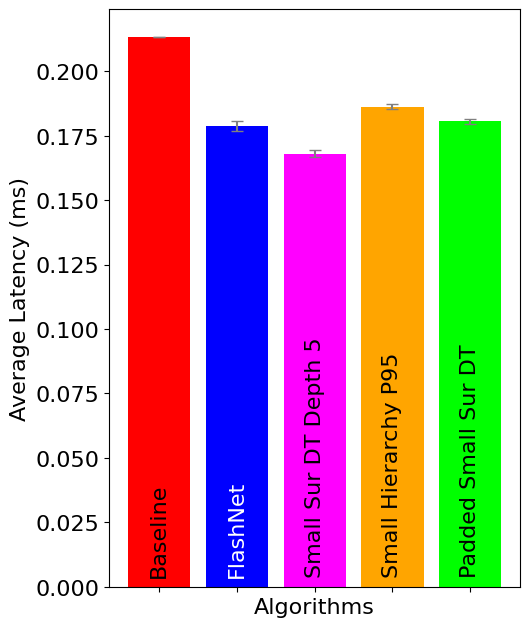

In [7]:
plt.rcParams.update({'font.size': 16})

algos = ['baseline', 'flashnet', 'small_surrogate_dt_depth5', 'small_hierarchy_p95', 'padded_small_surrogate_dt']
label = ['Baseline', 'FlashNet', 'Small Sur DT Depth 5', 'Small Hierarchy P95', 'Padded Small Sur DT']
font_colors = ['black', 'white', 'black', 'black', 'black']
colors = ['red', 'blue', 'magenta', 'orange', 'lime']

metric = "avg"
metric_std = metric + "_std"

yerr_values = std_collection.reindex(algos)[metric_std].values / 1000
yerr_values = [0 if algo == 'baseline' else err for algo, err in zip(algos, yerr_values)]

fig, ax = plt.subplots(figsize=(5.3, 7.5))
ax.bar(algos, mean_ms[metric], label=label, color=colors, yerr=yerr_values, capsize=4, ecolor='gray')
# ax.set_title('Latency at '+ metric +' (Light-Light)')
ax.set_ylabel('Average Latency (ms)')
# ax.set_ylim(0, 0.5)
# ax.set_yticklabels(["0", ".1", ".2", ".3", ".4", ".5"])
ax.set_xticklabels(label, rotation=90)
ax.set_xlabel('Algorithms')
ax.tick_params(axis='x', which='major', pad=-10)
for ticklabel, tickcolor in zip(fig.gca().get_xticklabels(), font_colors):
    ticklabel.set_color(tickcolor)
    ticklabel.set_horizontalalignment("center")
    ticklabel.set_verticalalignment("bottom")
# plt.text(-0.75, 0.5125, "(d) Light-Heavy", fontweight='bold')
# plt.text(4.72, 0.165, "et", rotation=90)
plt.savefig(os.path.join("eval-client-avg.eps"), dpi=200, bbox_inches='tight', format='eps')
plt.show()

['Baseline', 'FlashNet', 'Small Sur DT Depth 5', 'Small Hierarchy P95', 'Padded Small Sur DT']


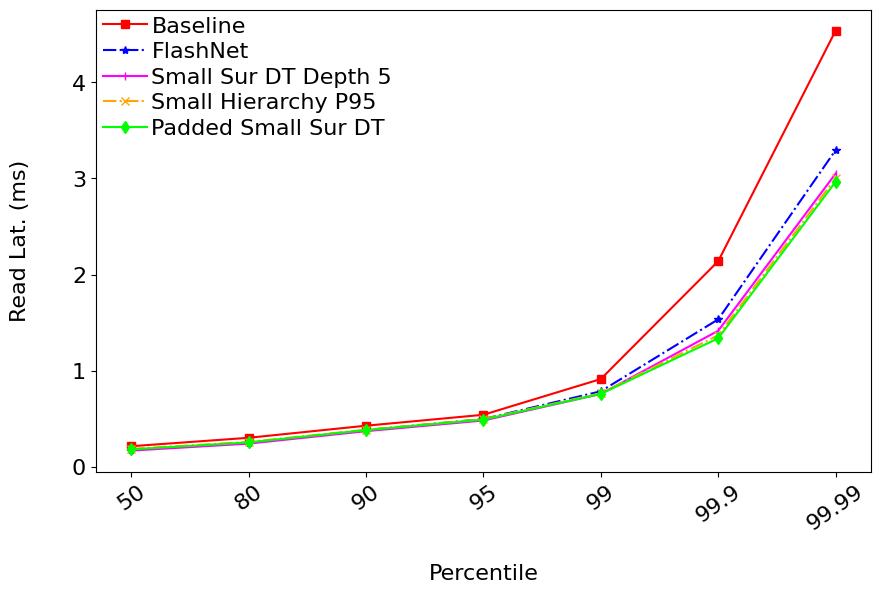

In [8]:
# Draw baseline vs flashnet line chart

algos = ['baseline', 'flashnet', 'small_surrogate_dt_depth5', 'small_hierarchy_p95', 'padded_small_surrogate_dt']
line_legend = ['Baseline', 'FlashNet', 'Small Sur DT Depth 5', 'Small Hierarchy P95', 'Padded Small Sur DT']
colors = ['red', 'blue', 'magenta', 'orange', 'lime']
styles = [
    's-',   # Baseline
    '*-.',  # FlashNet
    '|-',   # Small Sur DT Depth 5
    'x-.',  # Small Hierarchy P95
    'd-'   # Padded Small Sur DT
]

x_labels = ["avg", "p80.0", "p90.0", "p95.0", "p99.0", "p99.9", "p99.99"]
x_ticks = ["50", "80", "90", "95", "99", "99.9", "99.99"]

fig, ax = plt.subplots(figsize=(10, 6))
for idx, algo in enumerate(algos):
    ax.plot(np.arange(len(x_labels)), mean_ms.loc[algo][x_labels].values, styles[idx], label=line_legend[idx], color=colors[idx], linewidth=1.5)

handles, labels = ax.get_legend_handles_labels()
print(labels)

ax.legend([handles[0], handles[1], handles[2], handles[3], handles[4]], [labels[0], labels[1], labels[2], labels[3], labels[4]], loc='upper left', frameon=False, labelspacing=0.25, columnspacing=0.5, borderpad=-0.2, handletextpad=0.2, handlelength=2)
ax.set_xticks(np.arange(len(x_ticks)), x_ticks)
ax.set_xticklabels(x_ticks, rotation=35, ha='center')
# add y label
# ax.set_ylim(0, 8)
ax.set_ylabel("Read Lat. (ms)")
ax.set_xlabel("Percentile")
ax.xaxis.set_label_coords(0.5, -0.2)
ax.yaxis.set_label_coords(-0.085, 0.5)
plt.savefig(os.path.join("eval-client-line.eps"), dpi=200, bbox_inches='tight', format='eps')
plt.show()

['Baseline', 'FlashNet', 'Small Sur DT Depth 5', 'Small Hierarchy P95', 'Padded Small Sur DT']


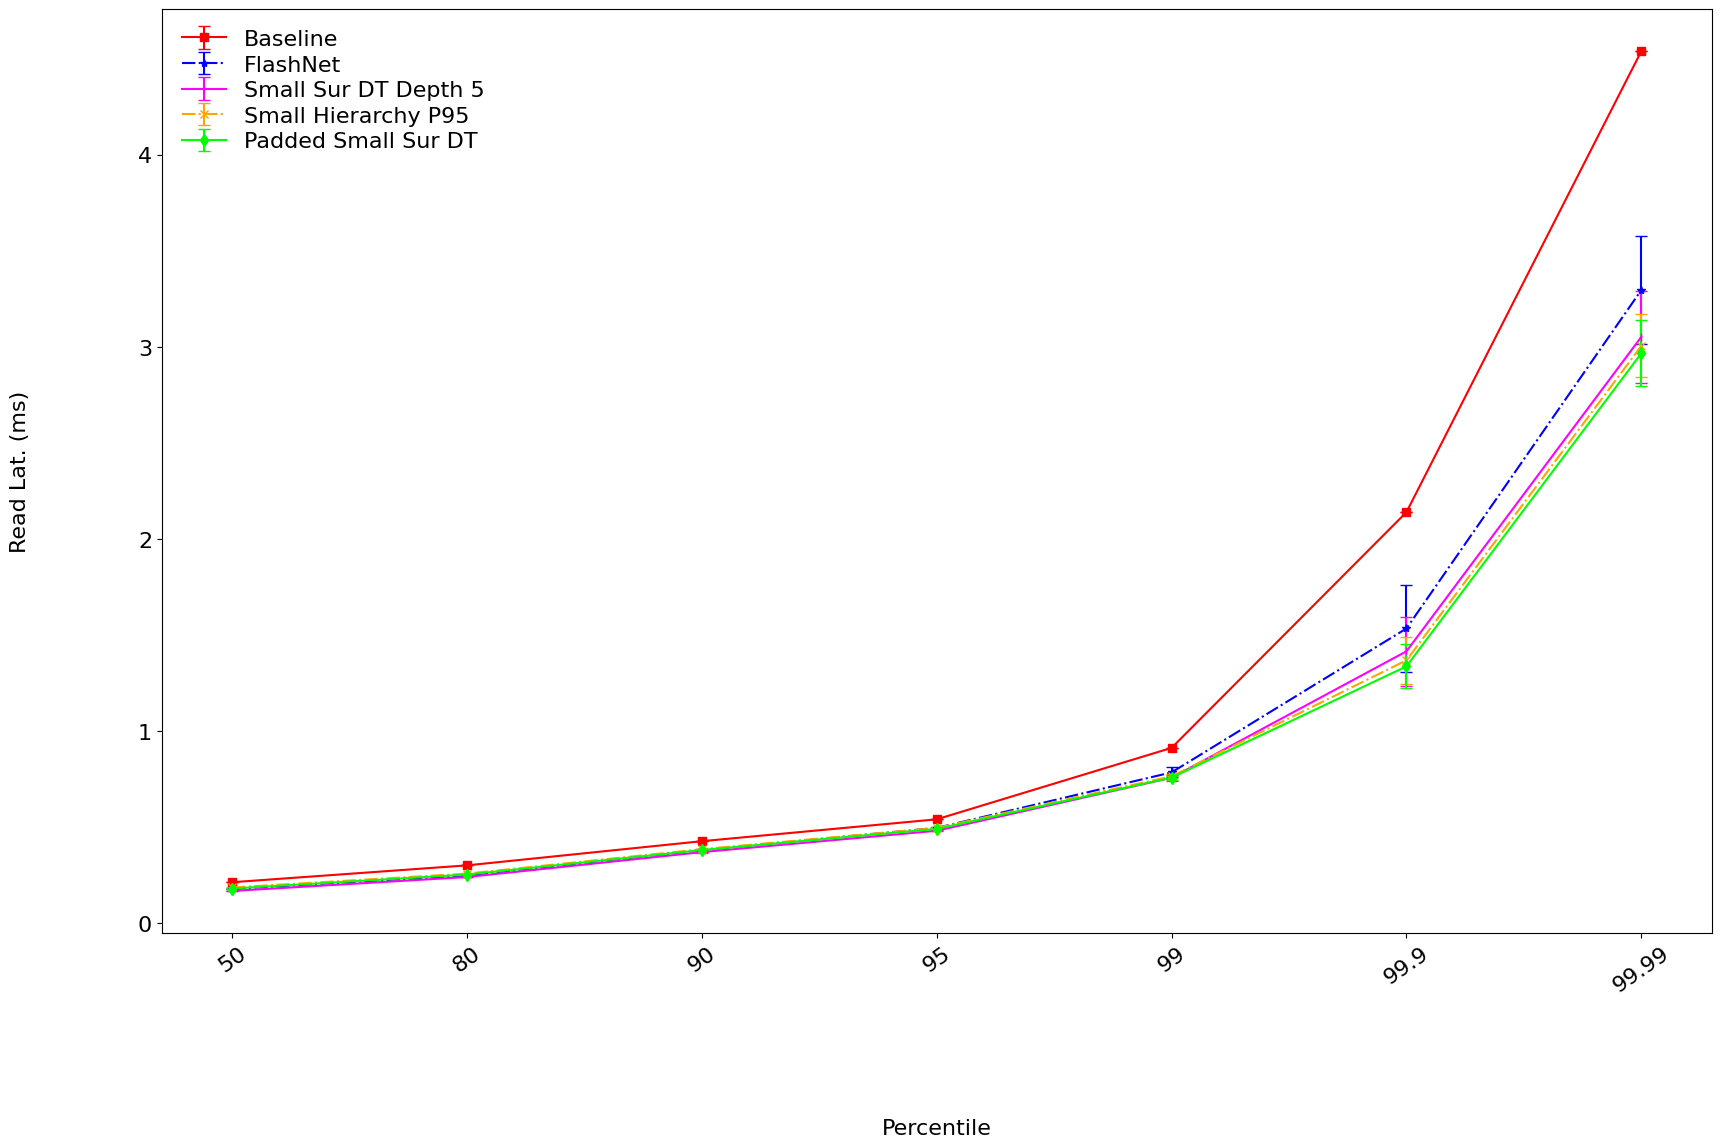

In [13]:
# Draw baseline vs flashnet line chart

algos = ['baseline', 'flashnet', 'small_surrogate_dt_depth5', 'small_hierarchy_p95', 'padded_small_surrogate_dt']
line_legend = ['Baseline', 'FlashNet', 'Small Sur DT Depth 5', 'Small Hierarchy P95', 'Padded Small Sur DT']
colors = ['red', 'blue', 'magenta', 'orange', 'lime']
styles = [
    's-',   # Baseline
    '*-.',  # FlashNet
    '|-',   # Small Sur DT Depth 5
    'x-.',  # Small Hierarchy P95
    'd-'    # Padded Small DT
]

x_labels = ["avg", "p80.0", "p90.0", "p95.0", "p99.0", "p99.9", "p99.99"]
x_ticks = ["50", "80", "90", "95", "99", "99.9", "99.99"]

x_labels_std = [lbl + "_std" for lbl in x_labels]

fig, ax = plt.subplots(figsize=(20, 12))
for idx, algo in enumerate(algos):
    y_values = mean_ms.loc[algo][x_labels].values
    yerr_values = std_collection.loc[algo][x_labels_std].values / 1000
    if algo == 'baseline':
        yerr_values = np.zeros_like(yerr_values)
    ax.errorbar(np.arange(len(x_labels)), y_values, yerr=yerr_values,
                fmt=styles[idx], label=line_legend[idx], color=colors[idx],
                linewidth=1.5, capsize=4, ecolor=colors[idx])

handles, labels = ax.get_legend_handles_labels()
print(labels)

ax.legend([handles[0], handles[1], handles[2], handles[3], handles[4]], [labels[0], labels[1], labels[2], labels[3], labels[4]], loc='upper left', frameon=False, labelspacing=0.25, ncol=1)
ax.set_xticks(np.arange(len(x_ticks)), x_ticks)
ax.set_xticklabels(x_ticks, rotation=35, ha='center')
# add y label
# ax.set_ylim(0, 8)
ax.set_ylabel("Read Lat. (ms)")
ax.set_xlabel("Percentile")
ax.xaxis.set_label_coords(0.5, -0.2)
ax.yaxis.set_label_coords(-0.085, 0.5)
plt.savefig(os.path.join("eval-client-line.eps"), dpi=200, bbox_inches='tight', format='eps')
plt.show()